## Introduction

This project investigates the predictive power of high-frequency limit order book (LOB) data in forecasting short-term price movements of equities. The main research goal is to determine whether engineered microstructure features can effectively predict whether the mid-price (at Time t) will increase in the next tick (at Time t+1). We will test this on multiple ML models

A set of domain-specific features was constructed, including:

* **Normalized spread**: captures market liquidity conditions
* **Volume imbalance**: reflects supply-demand asymmetry
* **Smart price**: weighted price estimation using depth
* **Trade pressure**: directional force behind price moves (Trade Pirce - at time t+0.5, t<t+0.5<t+1)
* **Signed volume**: net aggressiveness of trade initiators
* **Momentum**: short-term change in the mid-price

The prediction target is binary: `1` if the mid-price increases in the next time step (t+1), `0` otherwise. Performance is assessed primarily using **accuracy**, **F1-score**, and **AUC (Area Under ROC Curve)**, with additional analysis via confusion matrices under various decision thresholds. We will also test the models on the out-of-sample data in June to see if the models have further general predictability. Additionally, the project and its objective are insipired by **Machine Learning for Market Microstructure and High Frequency Trading** by Michael Kearns & Yuriy Nevmyvaka

## Model Comparison and Selection

Three machine learning models were trained and evaluated:

* **Logistic Regression** serves as a linear baseline. It is easy to interpret and reveals some predictive signal in the features, but lacks capacity to model complex patterns.
* **Random Forest** is a non-linear ensemble model. It captures interactions among features and provides feature importance scores, but tends to favor the majority class unless tuned with care.
* **Neural Network** (multi-layer perceptron) offers better balance between precision and recall, and adapts well to shifting distributions. It slightly outperforms other models in generalization to out-of-sample data.

### Extract Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
trade_mar = pd.read_csv('ytmorjhifybwowxl_csv.zip')
trade_jun = pd.read_csv('kdtqhpb4rhjkzbru_csv.zip')
quote_mar = pd.read_csv('yelqwtp7fsh6g6xo_csv.zip')
quote_jun = pd.read_csv('j9qkauhluxk44skr_csv.zip')


In [3]:
display(trade_mar.head())
display(quote_mar.head())


,DATE,TIME_M,SYM_ROOT,SYM_SUFFIX,TR_SCOND,SIZE,PRICE,TR_CORR
0,2024-03-12,9:30:01.020451429,AVT,NaN,@O X,2154,47.15,0
1,2024-03-12,9:30:01.020466092,AVT,NaN,@ Q,2154,47.15,0
2,2024-03-12,9:30:01.114610091,AVT,NaN,@ I,14,47.12,0
3,2024-03-12,9:30:01.446551389,AVT,NaN,@ I,26,46.97,0
4,2024-03-12,9:30:01.449122452,AVT,NaN,@ I,15,46.97,0


,DATE,TIME_M,BID,BIDSIZ,ASK,ASKSIZ,SYM_ROOT,SYM_SUFFIX
0,2024-03-12,3:59:00.167759885,0.00,0,0.00,0,AVT,NaN
1,2024-03-12,3:59:00.184257669,0.00,0,0.00,0,AVT,NaN
2,2024-03-12,4:05:08.486254529,19.23,1,0.00,0,AVT,NaN
3,2024-03-12,4:05:08.486265821,19.23,1,74.57,1,AVT,NaN
4,2024-03-12,4:05:08.486506828,20.62,1,74.57,1,AVT,NaN


## Data Cleaning & Preprocessing

The dataset contains millisecond-level TAQ (Trade and Quote) data. To prepare it for modeling:

1. TIMESTAMP fields were created by combining DATE and TIME\_M, enabling precise time alignment.
2. Both trade and quote data were sorted chronologically to maintain order.
3. Using pd.merge\_asof with 'backward' direction and grouped by SYM\_ROOT, each trade was matched to the most recent quote at or before its time.
4. Only data from 09:30 to 10:30 was kept to focus on the high-activity opening hour.
5. Rows with ASK == 0 were dropped, as these indicate invalid or missing quote entries.
6. The merged dataset was re-sorted by SYM\_ROOT and TIMESTAMP to ensure sequential order before feature generation.

This process yields a clean, time-aligned dataset suitable for microstructure-based feature extraction and modeling.

In [4]:
quote_mar['TIMESTAMP'] = pd.to_datetime(quote_mar['DATE'] + ' ' + quote_mar['TIME_M'].astype(str))
trade_mar['TIMESTAMP'] = pd.to_datetime(trade_mar['DATE'] + ' ' + trade_mar['TIME_M'].astype(str))

quote_mar = quote_mar.sort_values('TIMESTAMP')
trade_mar = trade_mar.sort_values('TIMESTAMP')


In [5]:
merge_mar = pd.merge_asof(trade_mar, quote_mar, on='TIMESTAMP', by='SYM_ROOT', direction='backward')
merge_mar = merge_mar[
    (merge_mar['TIMESTAMP'].dt.time >= pd.to_datetime("09:30:00").time()) &
    (merge_mar['TIMESTAMP'].dt.time <= pd.to_datetime("10:30:00").time())
]
merge_mar = merge_mar.sort_values(by=['SYM_ROOT', 'TIMESTAMP'])
merge_mar = merge_mar[merge_mar['ASK'] != 0]


## Feature Engineering & Label Construction

1. Mid-price & Spread:

* 'b\_a\_avg': Mid-price = (ASK + BID) / 2
* 'spread': Normalized bid-ask spread = (ASK - BID) / mid-price

2. Volume-related signals:

* 'vol\_imbalance': Difference in bid/ask sizes
* 'smart': Smart price estimate = weighted average of BID/ASK using sizes

3. Price pressure & directional volume:

* 'tra\_pressure': How far the trade price deviates from the mid-price, normalized by spread
* 'signed\_vol': Directional signed volume = price sign × size

4. Momentum:

* 'momentum': Rolling percentage change of mid-price within each stock

5. Forward-looking labels (look-ahead shift):

* 'next\_mid': Mid-price in the next row per stock
* 'next\_tra': Trade price in the next row per stock
* 'movement': Binary label = 1 if next\_mid > current\_mid, else 0
* 'price\_pct': Relative price change of the trade
* 'mid\_pct': Relative change of mid-price
* 'tra\_movement': Price direction based on next trade price

6. Data sanitization:

* 'row\_num': Counter for each row per symbol
* Only retain rows where 'row\_num' < max per symbol → avoids target leakage from last row

In [6]:
merge_mar['b_a_avg'] = (merge_mar['ASK'] + merge_mar['BID'])/2 # mid price
merge_mar['spread'] = ((merge_mar['ASK'] - merge_mar['BID'])/((merge_mar['ASK'] + merge_mar['BID'])/2)) # normalised bid-ask spread
merge_mar['vol_imbalance'] = (merge_mar['BIDSIZ'] - merge_mar['ASKSIZ']) / (merge_mar['BIDSIZ'] + merge_mar['ASKSIZ']) # volume imbalance
merge_mar['smart'] = (merge_mar['ASK'] * merge_mar['BIDSIZ'] + merge_mar['BID'] * merge_mar['ASKSIZ'])/(merge_mar['BIDSIZ']+merge_mar['ASKSIZ'])# smart price
merge_mar['tra_pressure'] = (merge_mar['PRICE'] - merge_mar['b_a_avg']) / merge_mar['spread']
merge_mar['signed_vol'] = np.sign(merge_mar['PRICE'] - merge_mar['b_a_avg']) * merge_mar['SIZE']
merge_mar['momentum'] = merge_mar.groupby('SYM_ROOT')['b_a_avg'].pct_change().fillna(0)

merge_mar['next_mid'] = merge_mar.groupby('SYM_ROOT')['b_a_avg'].shift(-1)
merge_mar['next_tra'] = merge_mar.groupby('SYM_ROOT')['PRICE'].shift(-1)
merge_mar.dropna(subset='next_tra')
merge_mar['movement'] = (merge_mar['next_mid'] > merge_mar['b_a_avg']).astype(int)
merge_mar['price_pct'] =  (merge_mar['next_tra'] - merge_mar['PRICE']) / merge_mar['PRICE']
merge_mar['mid_pct'] = (merge_mar['next_mid'] - merge_mar['b_a_avg']) / merge_mar['b_a_avg']
merge_mar['tra_movement'] = (merge_mar['next_tra'] > merge_mar['PRICE']).astype(int)


merge_mar['row_num'] = merge_mar.groupby('SYM_ROOT').cumcount()
max_row_num = merge_mar.groupby('SYM_ROOT')['row_num'].transform('max')
merge_mar = merge_mar[merge_mar['row_num'] < max_row_num]
merge_mar = merge_mar.drop(columns=['row_num'])

print(merge_mar['spread'].shape)
print(merge_mar['vol_imbalance'].shape)
print(merge_mar['smart'].shape)
print(merge_mar['tra_pressure'].shape)
print(merge_mar['movement'].shape)


(74267,)
(74267,)
(74267,)
(74267,)
(74267,)


## Model Training and Evaluation

### Logistic Regression

The first model trained is a logistic regression classifier. It serves as a baseline linear model to evaluate whether the engineered microstructure features contain any predictive power for short-term price movements.

* Features used include: normalized spread, volume imbalance, smart price, trade pressure, signed volume, and momentum.
* The input features were standardized using `StandardScaler`.
* The model was trained with L2 regularization (`penalty='l2'`).
* The classification target is whether the mid-price will increase in the next tick.

**Train accuracy:** 0.686
**Test accuracy:** 0.719

This indicates that the model performs marginally better than random guessing, and the features do contain weak but exploitable information.

The later cell exams the coefficients of features, and it turns out that trade pressure is the most important feature.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score

features = ['spread','vol_imbalance','smart','tra_pressure','signed_vol','momentum']
X = merge_mar[features].copy()
y = merge_mar['movement']

tscv = TimeSeriesSplit(n_splits=4) # for time-series data

train_scores = []
test_scores = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(penalty='l2')
    model.fit(X_train_scaled, y_train)
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_score = accuracy_score(y_train, y_train_pred)
    test_score = accuracy_score(y_test, y_test_pred)
    
    train_scores.append(train_score)
    test_scores.append(test_score)

print('train score:', sum(train_scores)/len(train_scores))
print('test score:', sum(test_scores)/len(test_scores))


train score: 0.6858796193190243
test score: 0.7190634888574698


In [8]:
pd.Series(model.coef_[0], index=['spread','vol_imbalance','smart','tra_pressure','signed_vol','momentum']).sort_values(ascending=False)
# feature coefficients


tra_pressure     0.534148
spread           0.204255
vol_imbalance    0.101895
signed_vol       0.013864
momentum         0.006320
smart           -0.052932
dtype: float64

### Random Forest

The second model is a Random Forest classifier, which is capable of capturing non-linear interactions among features and provides feature importance scores.

* Parameters include: `n_estimators=100`, `max_depth=6`, `min_samples_leaf=100`, `bootstrap=True`.
* Feature scaling was retained (though not strictly required for tree-based models) for consistency.
* After training on the same feature set, the model’s predictions were evaluated on the held-out test set.

**Train accuracy:** 0.7153  
**Test accuracy:** 0.7404

Compared to logistic regression, the random forest achieved higher performance and better recall, with clear insights into which features drive the model

In [9]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest
train_scores = []
test_scores = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    rf_model = RandomForestClassifier(n_estimators=100, 
                                       max_leaf_nodes=None,
                                       max_depth=6,
                                       min_samples_leaf=100,
                                       bootstrap=True,
                                       random_state=42, n_jobs=6)
    rf_model = rf_model.fit(X_train_scaled, y_train)
    
    y_train_pred =  rf_model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_score = rf_model.score(X_train_scaled,y_train)
    test_score = rf_model.score(X_test_scaled,y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)

print('train score:', sum(train_scores)/len(train_scores))
print('test score:', sum(test_scores)/len(test_scores))


train score: 0.7152640802924013
test score: 0.7404228102066922


### Neural Network

Since the logistic regression is a linear model, it is not fair to compare it with the random forest model - which is non-linear. We hence need to upgrade it to a better developed model - a neural network model with the output layer of a sigmoid function (the fundamental function of the logistic regression)

The final model is a feedforward neural network with three hidden layers:

* Layer architecture: Dense(25) → Dense(10) → Dense(3) → Dense(1)
* Activation functions: ReLU in hidden layers, sigmoid in output
* Loss function: Binary crossentropy
* Optimizer: Adam
* The model outputs a probability of mid-price increasing.

After training for 20 epochs with early stopping considerations, the network was evaluated:

**Test accuracy:** 0.7259  
**Train accuracy:** 0.6937

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

epochs = 15
batch_size = 16 
train_accs = []
test_accs = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    inputs = tf.keras.Input(shape=(len(features),))
    x = tf.keras.layers.Dense(25, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(inputs)
    x = tf.keras.layers.Dense(10, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = tf.keras.layers.Dense(5, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    
    nn_model = tf.keras.Model(inputs=inputs, outputs=outputs)
    nn_model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    
    
    train_history = nn_model.fit(X_train_scaled, y_train,
                           validation_data=(X_test_scaled, y_test),
                           epochs=epochs,
                           batch_size=batch_size,
                           verbose=1)

    y_train_pred =  nn_model.predict(X_train_scaled)
    y_test_pred = nn_model.predict(X_test_scaled)
    
    train_loss, train_acc = nn_model.evaluate(X_train_scaled, y_train, verbose=0)
    test_loss, test_acc = nn_model.evaluate(X_test_scaled, y_test, verbose=0)
    
    train_accs.append(train_acc)
    test_accs.append(test_acc)

print('train score:', sum(train_accs)/len(train_accs))
print('test score:', sum(test_accs)/len(test_accs))


Epoch 1/15
929/929 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6918 - loss: 0.6108 - val_accuracy: 0.6753 - val_loss: 0.6187
Epoch 2/15
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6953 - loss: 0.5919 - val_accuracy: 0.6737 - val_loss: 0.6098
Epoch 3/15
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6971 - loss: 0.5872 - val_accuracy: 0.6737 - val_loss: 0.6061
Epoch 4/15
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6962 - loss: 0.5841 - val_accuracy: 0.6747 - val_loss: 0.6075
Epoch 5/15
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6957 - loss: 0.5817 - val_accuracy: 0.6732 - val_loss: 0.6026
Epoch 6/15
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6984 - loss: 0.5803 - val_accuracy: 0.6735 - val_loss: 0.6018
Epoch 7/15
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6975 - loss: 0.5794 - val_accuracy: 0.6736 - val_loss: 0.6035
Epoch 8/15
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6997 - loss: 0.5787 - val_accuracy: 0.

### Neural Network Training Dynamics

During training, we monitored both the training and validation performance of the neural network over 15 epochs. Two key metrics were tracked:

* Loss over Epochs

The training loss started around 0.61 and decreased slowly to around 0.56, indicating a **shallow improvement** on the training data. In contrast, the **validation loss remained consistently lower** than the training loss and fluctuated mildly between **0.48 and 0.51**. This suggests that the model generalized well from the start and did not overfit, but it also implies that the **training loss plateaued early**, likely due to strong regularization or model capacity limits.

* Accuracy over Epochs

raining accuracy hovered narrowly between **67.4% and 71%**, showing **minimal learning progress** over time. Interestingly, the validation accuracy was consistently higher, around **78.3%**, and remained very stable with negligible variation. The **inverted generalization gap** (validation > training) implies that either:

1. The validation set was easier or more favorable,
2. Or the model is underfitting the training data slightly, possibly due to **strong L2 regularization (λ = 0.001)** or conservative network depth.

* The learning curves suggest the following:

The model did not overfit, and generalization was stable throughout training.
The training progress was weak, likely due to model undercapacity or overly strong regularization.
The high and stable validation accuracy suggests the model still captures reliable patterns from the microstructure data.

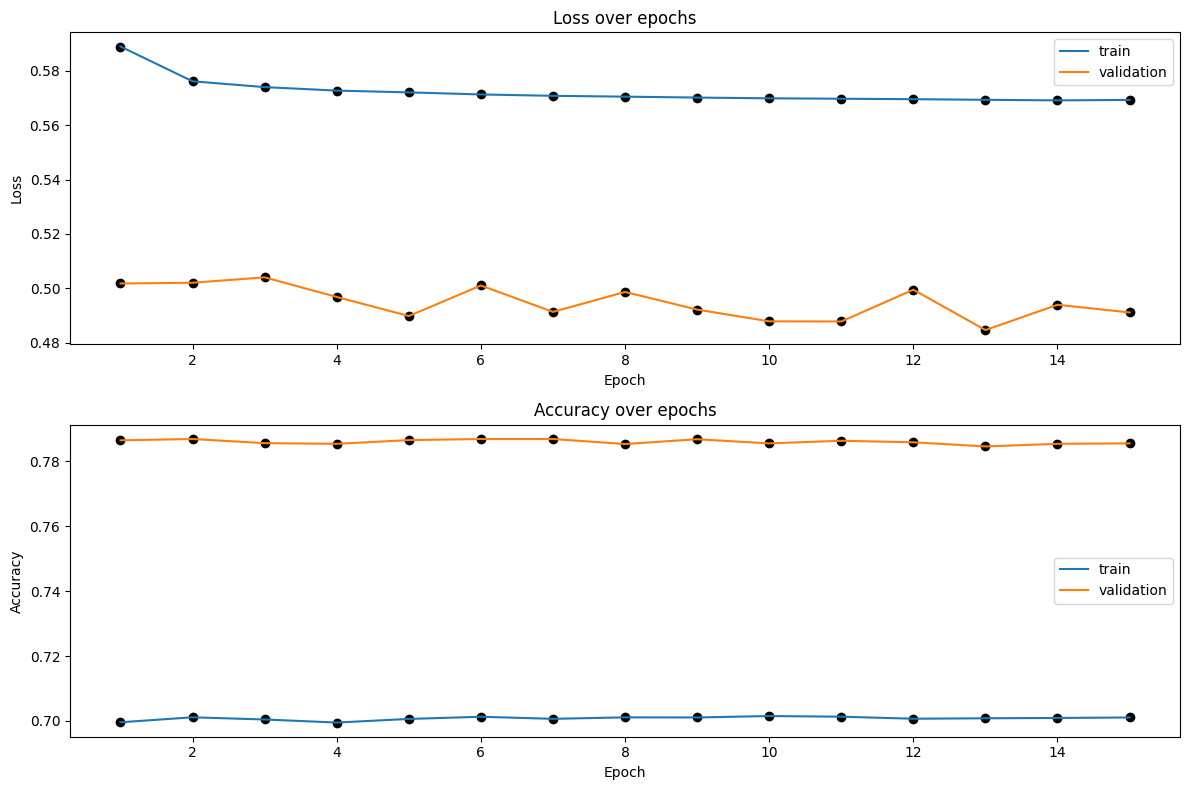

In [11]:
# The last group of epochs

epochs = np.arange(1, 16)
fig = plt.figure(figsize=(12, 8))

# Plot loss
ax1 = plt.subplot(211)
ax1.plot(epochs, train_history.history["loss"], label="train")
ax1.plot(epochs, train_history.history["val_loss"], label="validation")
ax1.scatter(epochs, train_history.history["loss"], color="black")
ax1.scatter(epochs, train_history.history["val_loss"], color="black")
ax1.set_title("Loss over epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# Plot accuracy
ax2 = plt.subplot(212)
ax2.plot(epochs, train_history.history["accuracy"], label="train")
ax2.plot(epochs, train_history.history["val_accuracy"], label="validation")
ax2.scatter(epochs, train_history.history["accuracy"], color="black")
ax2.scatter(epochs, train_history.history["val_accuracy"], color="black")
ax2.set_title("Accuracy over epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

fig.tight_layout()
plt.show()


### ROC Curve Analysis – Neural Network

To evaluate the discrimination ability of the neural network classifier across varying thresholds, we plotted the Receiver Operating Characteristic (ROC) curves for both the training and test sets. The Area Under the Curve (AUC) serves as a threshold-independent performance metric.

* Training ROC Curve

The ROC curve on the training set shows a smooth and concave profile, with an AUC of 0.69. This indicates that the model has learned meaningful patterns from the data and is capable of distinguishing between the two classes (mid-price up vs. not up) to a reasonable extent. The curve lies well above the diagonal baseline, confirming a performance clearly better than random guessing.

* Test ROC Curve

On the test set, the AUC slightly improves to 0.71, which aligns with earlier findings that validation accuracy exceeded training accuracy. The test ROC curve preserves the overall shape and curvature of the training curve, suggesting that the model generalizes well. The small and reverse generalization gap (test > train) further confirms that the model is not overfitting.

* Conclusion

The neural network demonstrates stable and reliable classification behavior across both in-sample and out-of-sample data. An AUC around 0.71 confirms that the model captures moderately strong signal structures in the high-frequency market data, making it suitable for probabilistic output-driven prediction and threshold-based trading logic.

1857/1857 ━━━━━━━━━━━━━━━━━━━━ 1s 641us/step
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step


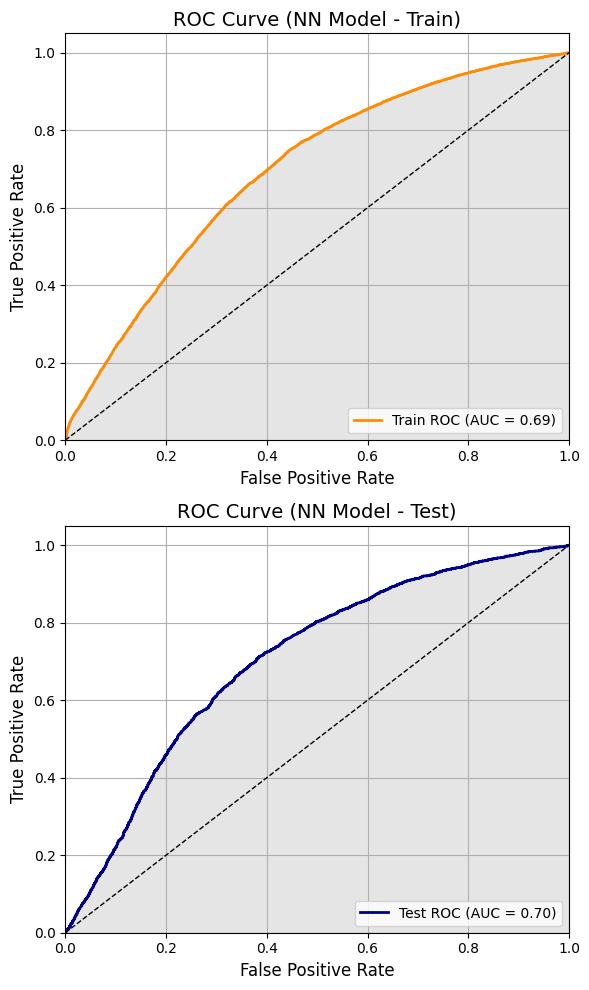

In [12]:
from sklearn.metrics import roc_curve, auc

y_train_prob = nn_model.predict(X_train_scaled).flatten()
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
roc_auc_train = auc(fpr_train, tpr_train)
y_test_prob = nn_model.predict(X_test_scaled).flatten()
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(6, 10))

plt.subplot(2, 1, 1)
plt.plot(fpr_train, tpr_train, label='Train ROC (AUC = {:.2f})'.format(roc_auc_train), color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.fill_between(fpr_train, tpr_train, alpha=0.2, color='grey')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve (NN Model - Train)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(fpr_test, tpr_test, label='Test ROC (AUC = {:.2f})'.format(roc_auc_test), color='darkblue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.fill_between(fpr_test, tpr_test, alpha=0.2, color='grey')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve (NN Model - Test)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()


### ROC Curve Analysis – Random Forest

To evaluate the discrimination ability of the random forest classifier across varying thresholds, we plotted the Receiver Operating Characteristic (ROC) curves for both the training and test sets. The Area Under the Curve (AUC) provides a threshold-independent assessment of classification quality.

* Training ROC Curve

The ROC curve on the training set has a smooth, concave shape with an AUC of 0.73. This indicates that the random forest model has effectively captured discriminative patterns from the training data. The curve is well above the diagonal reference line, demonstrating performance that is clearly better than random chance, yet without signs of overfitting (e.g., AUC near 1.0).

* Test ROC Curve

On the test set, the AUC slightly improves to 0.74, indicating strong generalization. The shape of the test ROC curve closely mirrors that of the training set, reinforcing the model’s robustness. The small generalization gap and slightly better test performance suggest that the model benefited from ensemble regularization and is not sensitive to data variance.

* Conclusion

The random forest model shows solid discriminative ability on both training and unseen test data, with AUC values in the range of 0.73–0.74. These results confirm that the model can reliably identify microstructure patterns in high-frequency trading snapshots, and may serve as a strong benchmark or production-ready candidate for probabilistic classification tasks in this domain.

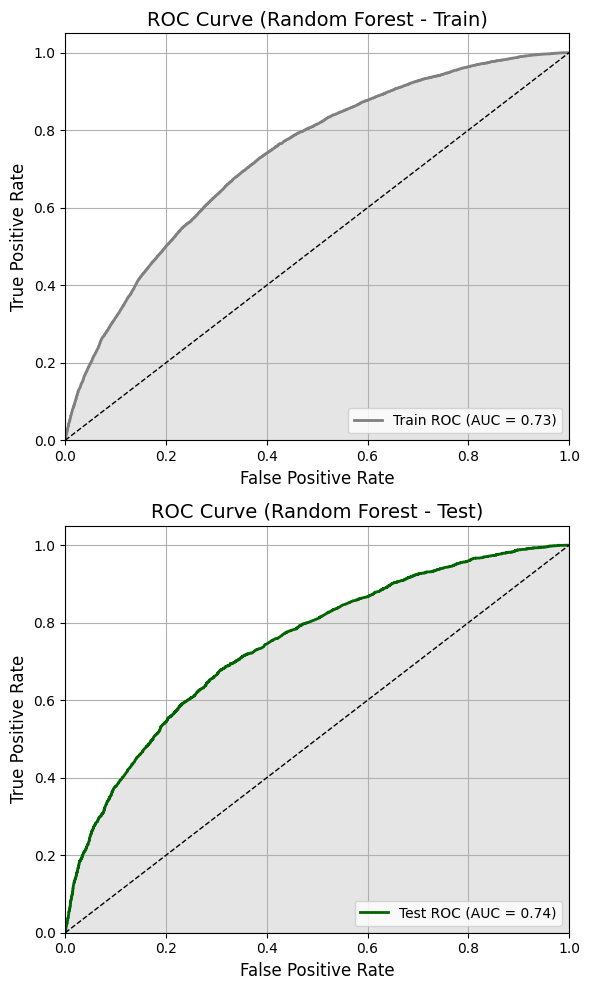

In [13]:
y_train_prob_rf = rf_model.predict_proba(X_train_scaled)[:, 1]
fpr_train_rf, tpr_train_rf, _ = roc_curve(y_train, y_train_prob_rf)
roc_auc_train_rf = auc(fpr_train_rf, tpr_train_rf)

y_test_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, y_test_prob_rf)
roc_auc_test_rf = auc(fpr_test_rf, tpr_test_rf)

plt.figure(figsize=(6, 10))

plt.subplot(2, 1, 1)
plt.plot(fpr_train_rf, tpr_train_rf, label='Train ROC (AUC = {:.2f})'.format(roc_auc_train_rf), color='grey', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.fill_between(fpr_train_rf, tpr_train_rf, alpha=0.2, color='grey')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve (Random Forest - Train)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

# Test subplot
plt.subplot(2, 1, 2)
plt.plot(fpr_test_rf, tpr_test_rf, label='Test ROC (AUC = {:.2f})'.format(roc_auc_test_rf), color='darkgreen', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.fill_between(fpr_test_rf, tpr_test_rf, alpha=0.2, color='grey')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve (Random Forest - Test)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()


### Neural Network Classification Performance at Different Thresholds

To evaluate the sensitivity and flexibility of the neural network's probabilistic output, we analyzed its classification performance under two different decision thresholds: the default 0.5 and a lower threshold of 0.4. This enables us to trade off between false positives and false negatives depending on the prediction goal.

1. Threshold = 0.5 (Default)

Using the standard 0.5 cutoff, the model exhibits extremely conservative behavior toward predicting class 1 (mid-price increase):

* Class 0 (no price increase) achieves near-perfect recall (0.9999) and high precision (0.7868), resulting in a strong F1-score of 0.8806.
* Class 1 (price increase) recall is essentially zero (0.0009), leading to a very low F1-score of 0.0019, despite precision of 0.7500 on the few positive predictions made.
* Overall accuracy is 0.7868, but this is driven almost entirely by the model’s success in detecting the majority class.
* The confusion matrix reveals **3166 false negatives** and only **3 true positives**, indicating a significant inability to detect upward price moves.

This threshold is unsuitable for any application that requires the model to reliably capture class 1 signals, such as trade entry points or breakout detection.

2. Threshold = 0.4 (Relaxed)

Lowering the threshold to 0.4 makes the model significantly more aggressive in predicting class 1:

* Class 1 recall improves from 0.0009 to **0.3115**, and precision rises to 0.3877, yielding an improved **F1-score of 0.3454**.
* Class 0 performance slightly decreases: recall drops to 0.8666 and precision to 0.8227, with F1-score at 0.8441.
* Overall accuracy falls modestly to 0.7481, which is acceptable given the boost in class 1 detection.
* The confusion matrix shows **987 true positives** and **2182 false negatives**, a clear improvement in capturing upward price events.

3. Conclusion

The comparison demonstrates how neural network behavior shifts with threshold adjustment. A 0.5 threshold optimizes specificity but nearly eliminates sensitivity to minority events. Conversely, a 0.4 threshold increases coverage of class 1 at the cost of some precision and overall accuracy. In financial applications where missing an upward signal is more costly than a false alarm, threshold tuning—especially toward recall optimization—is crucial for effective deployment.

In [14]:
print('NN weights:', len(nn_model.get_weights()))


NN weights: 8


              precision    recall  f1-score   support

           0     0.7873    0.9966    0.8797     11684
           1     0.3651    0.0073    0.0142      3169

    accuracy                         0.7855     14853
   macro avg     0.5762    0.5019    0.4469     14853
weighted avg     0.6972    0.7855    0.6950     14853

Confusion Matrix:


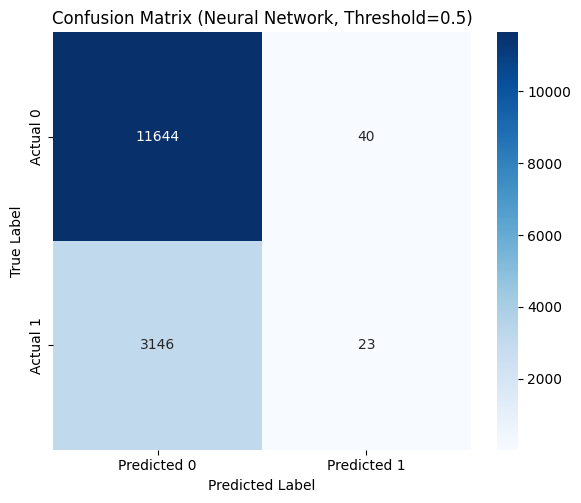

In [15]:
# Neural Network Precision/Recall + F1, from the last group of epochs
from sklearn.metrics import classification_report, confusion_matrix # Precision/Recall
import seaborn as sns
y_test_pred = (y_test_prob > 0.5).astype(int)
print(classification_report(y_test, y_test_pred, digits=4))
print("Confusion Matrix:") 
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix (Neural Network, Threshold=0.5)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0     0.8383    0.8227    0.8304     11684
           1     0.3882    0.4150    0.4012      3169

    accuracy                         0.7357     14853
   macro avg     0.6133    0.6188    0.6158     14853
weighted avg     0.7423    0.7357    0.7388     14853

Confusion Matrix:


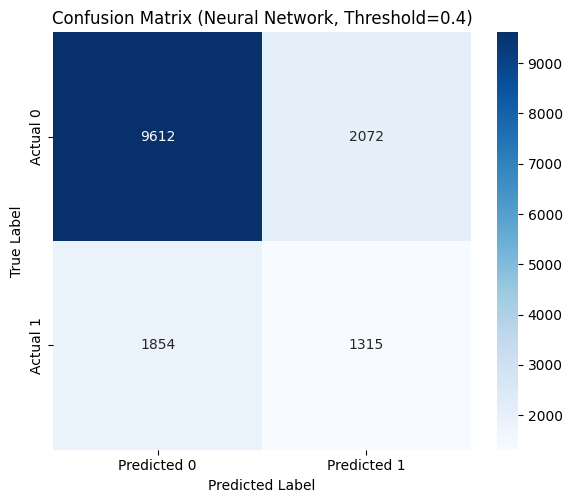

In [16]:
y_test_pred = (y_test_prob > 0.4).astype(int)
print(classification_report(y_test, y_test_pred, digits=4))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix (Neural Network, Threshold=0.4)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


## Feature Importance and Individual Tree Structure

The Random Forest model consists of 100 individual decision trees. Each tree learns different decision boundaries based on bootstrapped samples, and the final classification is made by aggregating their predictions.

To understand feature influence from two angles, we looked at:

* **Global Feature Importance**: Calculated by the forest as a whole using the `feature_importances_` attribute. This reflects the 'average reduction in Gini impurity' contributed by each feature across all trees.
* **Single Tree Structure**: Visualized one of the estimators (`estimators_[0]`) to gain interpretability on specific rule paths.

The importance scores showed that:

* `tra_pressure` was the most informative feature (importance ≈ 0.35), often used at the root of many trees.
* `signed_vol` and `momentum` also ranked highly, highlighting the significance of directional volume and short-term trend.
* Features like `spread`, `smart`, and `vol_imbalance` contributed less globally but were still used contextually in specific tree paths.

This comparison reveals how the random forest balances global pattern learning with diverse, localized decision paths across its ensemble structure.

In [17]:
feature_names = X_train.columns
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df)


         feature  importance
3   tra_pressure    0.385203
4     signed_vol    0.247250
5       momentum    0.227500
0         spread    0.069311
2          smart    0.055721
1  vol_imbalance    0.015015


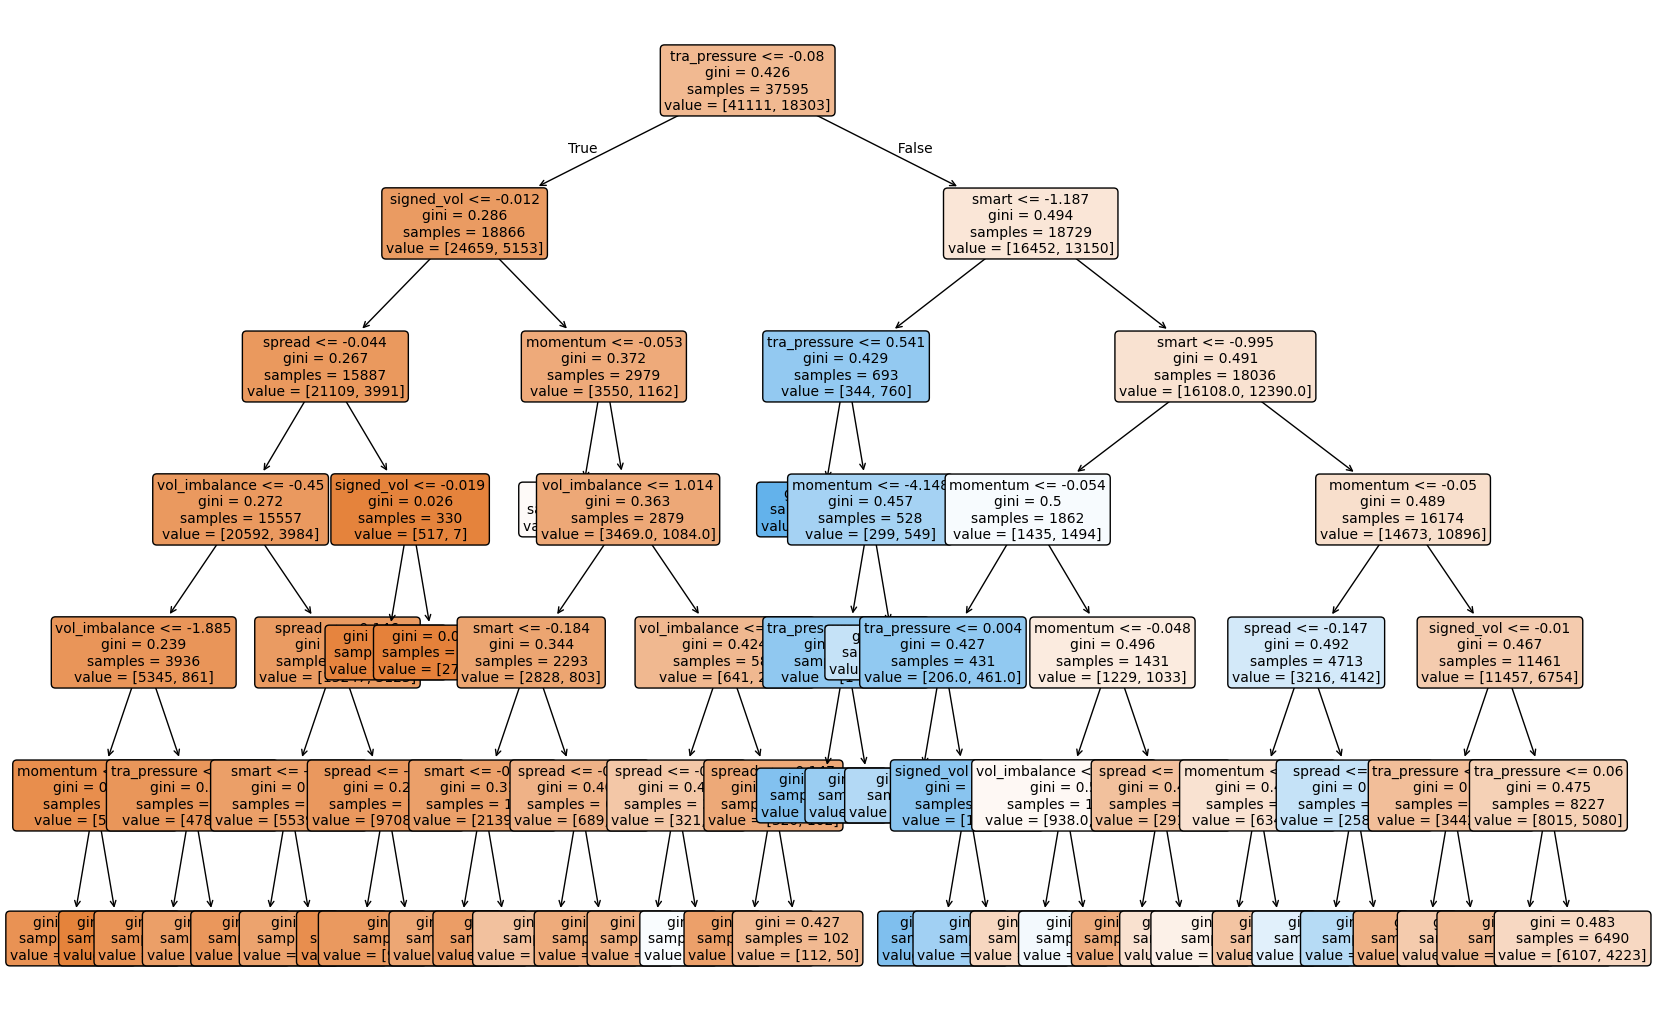

In [18]:
from sklearn import tree

single_tree = rf_model.estimators_[0]

plt.figure(figsize=(20, 13))
tree.plot_tree(
    single_tree,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=10)
plt.show()


### Random Forest Classification Performance at Different Thresholds

To evaluate how threshold adjustments affect the performance of the random forest model, we compared the classifier's results at the default threshold of 0.5 (predict class 1 if predicted probability > 0.5) and a relaxed threshold of 0.4. This allows for better detection of minority class events (class 1 – price increase) in imbalanced datasets.

1. Threshold = 0.5 (Default)

With the standard 0.5 threshold, the random forest is conservative in predicting class 1:

* Class 0 achieves strong precision (0.8048) and very high recall (0.9842), resulting in a high F1-score of 0.8855.
* Class 1 is predicted much less frequently, yielding recall of only 0.1199 and a low F1-score of 0.2035.
* Overall accuracy is 0.7998, and the macro-averaged F1-score is 0.5445, indicating poor balance between the classes.
* The confusion matrix shows **2789 false negatives**, meaning a large number of upward price movements were missed.

This default setting leads to low sensitivity in detecting class 1 events and may be unsuitable in trading strategies where signal coverage is critical.

2. Threshold = 0.4 (Relaxed)

Lowering the threshold to 0.4 makes the model more aggressive in predicting class 1:

* Class 1 recall increases substantially to 0.2562 (more than double), while precision decreases to 0.5747 due to more false positives.
* F1-score for class 1 improves to 0.3544, a significant increase compared to the default threshold.
* Class 0 performance remains relatively high (precision: 0.8246, recall: 0.9486).
* Overall accuracy remains strong at 0.8008, and the macro F1-score improves from 0.5445 to 0.6183.
* The confusion matrix shows **812 true positives** (vs. 380 before), while **false negatives drop to 2357**.

3. Conclusion

Threshold tuning meaningfully improves the performance of the random forest classifier for class 1 detection. Compared to the default 0.5 cutoff, the relaxed threshold of 0.4 strikes a better balance between precision and recall for the minority class without sacrificing overall accuracy. This makes the model more suitable for applications that require higher class 1 sensitivity, such as alert systems or trading signal generation.

Confusion Matrix:


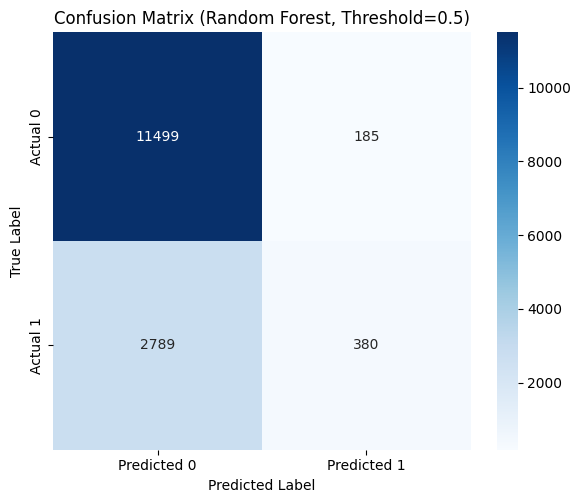

Classification Report:
              precision    recall  f1-score   support

           0     0.8048    0.9842    0.8855     11684
           1     0.6726    0.1199    0.2035      3169

    accuracy                         0.7998     14853
   macro avg     0.7387    0.5520    0.5445     14853
weighted avg     0.7766    0.7998    0.7400     14853



In [19]:
## Ramdom Forest Precision/Recall + F1

y_test_pred = rf_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix (Random Forest, Threshold=0.5)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

report = classification_report(y_test, y_test_pred, digits=4)
print("Classification Report:")
print(report)


Confusion Matrix:


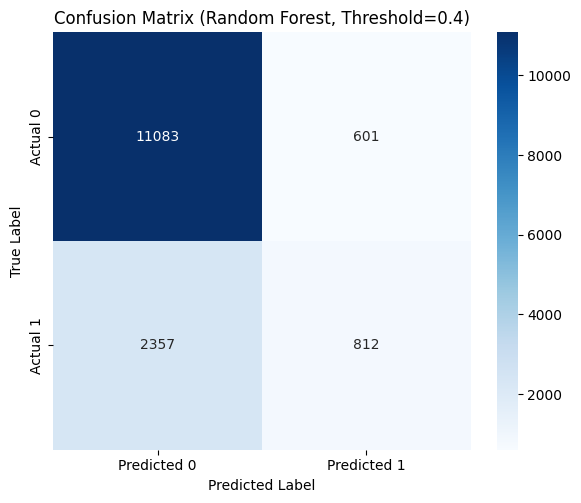

Classification Report:
              precision    recall  f1-score   support

           0     0.8246    0.9486    0.8823     11684
           1     0.5747    0.2562    0.3544      3169

    accuracy                         0.8008     14853
   macro avg     0.6996    0.6024    0.6183     14853
weighted avg     0.7713    0.8008    0.7696     14853



In [20]:
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
y_proba = (y_proba > 0.4).astype(int)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_proba)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix (Random Forest, Threshold=0.4)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

report = classification_report(y_test, y_proba, digits=4)
print("Classification Report:")
print(classification_report(y_test, y_proba, digits=4))


### July Data Cleasning (Out-of-Sample Testing))

In [21]:
quote_jun['TIMESTAMP'] = pd.to_datetime(quote_jun['DATE'] + ' ' + quote_jun['TIME_M'].astype(str))
trade_jun['TIMESTAMP'] = pd.to_datetime(trade_jun['DATE'] + ' ' + trade_jun['TIME_M'].astype(str))

quote_jun = quote_jun.sort_values('TIMESTAMP')
trade_jun = trade_jun.sort_values('TIMESTAMP')

merge_jun = pd.merge_asof(
    trade_jun, quote_jun,
    on='TIMESTAMP', by='SYM_ROOT', direction='backward'
)

merge_jun = merge_jun[
    (merge_jun['TIMESTAMP'].dt.time >= pd.to_datetime("09:30:00").time()) &
    (merge_jun['TIMESTAMP'].dt.time <= pd.to_datetime("10:30:00").time())
]

merge_jun = merge_jun[merge_jun['ASK'] != 0]
merge_jun['b_a_avg'] = (merge_jun['ASK'] + merge_jun['BID']) / 2
merge_jun['spread'] = (merge_jun['ASK'] - merge_jun['BID']) / ((merge_jun['ASK'] + merge_jun['BID']) / 2)
merge_jun['vol_imbalance'] = (merge_jun['BIDSIZ'] - merge_jun['ASKSIZ']) / (merge_jun['BIDSIZ'] + merge_jun['ASKSIZ'])
merge_jun['smart'] = (merge_jun['ASK'] * merge_jun['BIDSIZ'] + merge_jun['BID'] * merge_jun['ASKSIZ']) / (merge_jun['BIDSIZ'] + merge_jun['ASKSIZ'])
merge_jun['tra_pressure'] = (merge_jun['PRICE'] - merge_jun['b_a_avg']) / merge_jun['spread']
merge_jun['signed_vol'] = np.sign(merge_jun['PRICE'] - merge_jun['b_a_avg']) * merge_jun['SIZE']
merge_jun['momentum'] = merge_jun.groupby('SYM_ROOT')['b_a_avg'].pct_change().fillna(0)

merge_jun['next_mid'] = merge_jun.groupby('SYM_ROOT')['b_a_avg'].shift(-1)
merge_jun['next_tra'] = merge_jun.groupby('SYM_ROOT')['PRICE'].shift(-1)
merge_jun['movement'] = (merge_jun['next_mid'] > merge_jun['b_a_avg']).astype(int)
merge_jun['price_pct'] = (merge_jun['next_tra'] - merge_jun['PRICE']) / merge_jun['PRICE']
merge_jun['mid_pct'] = (merge_jun['next_mid'] - merge_jun['b_a_avg']) / merge_jun['b_a_avg']
merge_jun['tra_movement'] = (merge_jun['next_tra'] > merge_jun['PRICE']).astype(int)

merge_jun['row_num'] = merge_jun.groupby('SYM_ROOT').cumcount()
max_row_num = merge_jun.groupby('SYM_ROOT')['row_num'].transform('max')
merge_jun = merge_jun[merge_jun['row_num'] < max_row_num]
merge_jun = merge_jun.drop(columns=['row_num'])

display(merge_jun)


,DATE_x,TIME_M_x,SYM_ROOT,SYM_SUFFIX_x,TR_SCOND,SIZE,PRICE,TR_CORR,TIMESTAMP,DATE_y,...,smart,tra_pressure,signed_vol,momentum,next_mid,next_tra,movement,price_pct,mid_pct,tra_movement
7244,2024-07-11,9:30:00.001990937,AVT,NaN,@ TI,48,52.3500,0,2024-07-11 09:30:00.001990937,2024-07-11,...,51.177778,25.458816,48.0,0.000000,51.695,52.3600,0,0.000191,0.000000e+00,1
7245,2024-07-11,9:30:00.001992512,AVT,NaN,@ TI,93,52.3600,0,2024-07-11 09:30:00.001992512,2024-07-11,...,51.177778,25.847500,93.0,0.000000,52.020,51.9550,1,-0.007735,6.286875e-03,0
7247,2024-07-11,9:30:00.008155648,WMT,NaN,F I,5,70.3700,0,2024-07-11 09:30:00.008155648,2024-07-11,...,70.315000,14.323426,5.0,0.000000,70.245,70.4500,0,0.001137,-9.955202e-04,1
7248,2024-07-11,9:30:00.008540416,WMT,NaN,F I,5,70.4500,0,2024-07-11 09:30:00.008540416,2024-07-11,...,70.385263,35.122500,5.0,-0.000996,35.225,70.3150,0,-0.001916,-4.985408e-01,0
7249,2024-07-11,9:30:00.098857216,SAP,NaN,T,200,203.7900,0,2024-07-11 09:30:00.098857216,2024-07-11,...,203.810000,-40.762000,-200.0,0.000000,203.810,203.8300,0,0.000196,0.000000e+00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91273,2024-07-11,10:29:57.700947712,WMT,NaN,NaN,100,69.4000,0,2024-07-11 10:29:57.700947712,2024-07-11,...,69.383529,-6.941000,-100.0,0.000144,69.395,69.3950,0,-0.000072,-2.161072e-04,0
91274,2024-07-11,10:29:57.738257664,UNH,NaN,I,41,504.6713,0,2024-07-11 10:29:57.738257664,2024-07-11,...,504.455000,158.135676,41.0,0.000059,504.455,504.3536,0,-0.000630,0.000000e+00,0
91276,2024-07-11,10:29:58.006189568,WMT,NaN,I,7,69.3950,0,2024-07-11 10:29:58.006189568,2024-07-11,...,69.392000,0.000000,0.0,-0.000216,69.395,69.3950,0,0.000000,0.000000e+00,0
91281,2024-07-11,10:29:58.225381376,WMT,NaN,I,1,69.3950,0,2024-07-11 10:29:58.225381376,2024-07-11,...,69.390000,0.000000,0.0,0.000000,69.395,69.3950,0,0.000000,0.000000e+00,0


### Neural Network test on July data

Accuracy: 72.75%

In [22]:
# test on the data in june: logistic regression + neural networks
X = merge_jun[features]
Y = merge_jun['movement']
X_scaled = scaler.fit_transform(X)

loss, acc = nn_model.evaluate(X_scaled, Y, verbose=0)
print('score:', acc)


score: 0.726995587348938


## Out-of-Sample ROC Curve – Neural Network (July Data))

To evaluate the model’s generalization ability, the trained neural network was tested on out-of-sample data from July. The ROC curve plots the true positive rate (sensitivity) against the false positive rate for different threshold values.

1. The AUC (Area Under the Curve) is **0.70**, which indicates that the model maintains a moderate level of discriminatory power on unseen data.
2. The curve remains above the 45-degree diagonal baseline, confirming that the model performs significantly better than random guessing.
3. Compared to in-sample test AUC (0.70), this suggests **stable generalization**, with no severe overfitting.
4. The shape of the curve remains smooth, reflecting reliable probability output from the neural network.

* Conclusion

The ROC analysis on June data demonstrates that the neural network model preserves predictive value when applied to new, unseen periods. Although not highly confident, the AUC of 0.70 confirms that the engineered microstructure features retain consistent explanatory power across time.

2522/2522 ━━━━━━━━━━━━━━━━━━━━ 2s 674us/step


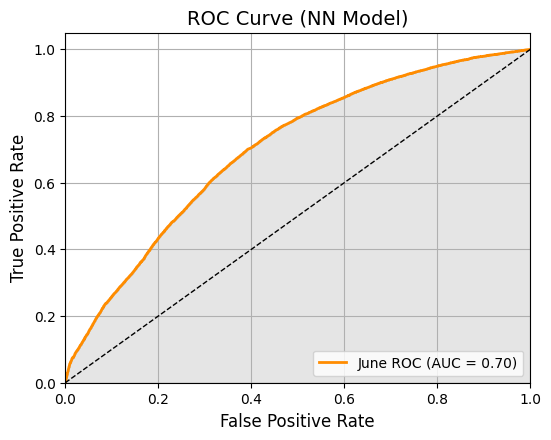

In [23]:
y_nn_prob = nn_model.predict(X_scaled).flatten()
fpr_train, tpr_train, _ = roc_curve(Y, y_nn_prob)
roc_auc_train = auc(fpr_train, tpr_train)

plt.figure(figsize=(6, 10))

plt.subplot(2, 1, 1)
plt.plot(fpr_train, tpr_train, label='June ROC (AUC = {:.2f})'.format(roc_auc_train), color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.fill_between(fpr_train, tpr_train, alpha=0.2, color='grey')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve (NN Model)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)


### Neural Network Performance at Different Thresholds (July Data))

To evaluate generalization ability, we tested the neural network trained on March data against unseen July data. As before, we compared classification results under two thresholds: 0.5 (default) and 0.4 (relaxed). This enables us to assess the model’s ability to detect upward price movement signals in real-world deployment scenarios.

1. Threshold = 0.5 (Default)

At the default threshold, the model maintained high accuracy but showed conservative behavior:

* Class 0 (no price increase) is predicted with high confidence, achieving **recall of 0.9807** and **precision of 0.7316**, producing a strong **F1-score of 0.8380**.
* Class 1 recall is extremely low at **0.0807**, and precision is 0.6210, resulting in a weak **F1-score of 0.1428**.
* Overall accuracy is 0.7275, heavily driven by correct classification of the majority class.
* The confusion matrix shows **20872 false negatives** and only **1832 true positives**, indicating the model fails to detect most price increases.

This threshold reflects strong bias toward class 0, making it suboptimal in contexts that value sensitivity to upward movements.

2. Threshold = 0.4 (Relaxed)

Reducing the threshold allows the model to be more responsive to potential price increases:

* Class 1 recall increases substantially to **0.5133**, and precision to 0.4430, resulting in an improved **F1-score of 0.4755**.
* Class 0 recall drops to 0.7473 and precision to 0.7968, with F1-score at 0.7713.
* Overall accuracy declines to 0.6815, but this is a favorable trade-off considering the boost in class 1 detection.
* The confusion matrix shows **11653 true positives** and **11051 false negatives**, a dramatic improvement over the default threshold.

3. Conclusion

The July out-of-sample test confirms that threshold tuning is essential for model robustness. While the default setting favors specificity and class 0 precision, it severely limits the model’s ability to identify rising price movements. A relaxed threshold of 0.4 recovers more than 50% of true positives, making the model far more viable for use in trading strategies where missed opportunities are costly. Despite a decrease in accuracy, the net gain in recall and F1-score for class 1 justifies the threshold adjustment in practice.

              precision    recall  f1-score   support

           0     0.7351    0.9694    0.8362     57998
           1     0.5797    0.1077    0.1816     22704

    accuracy                         0.7270     80702
   macro avg     0.6574    0.5386    0.5089     80702
weighted avg     0.6914    0.7270    0.6520     80702

Confusion Matrix:


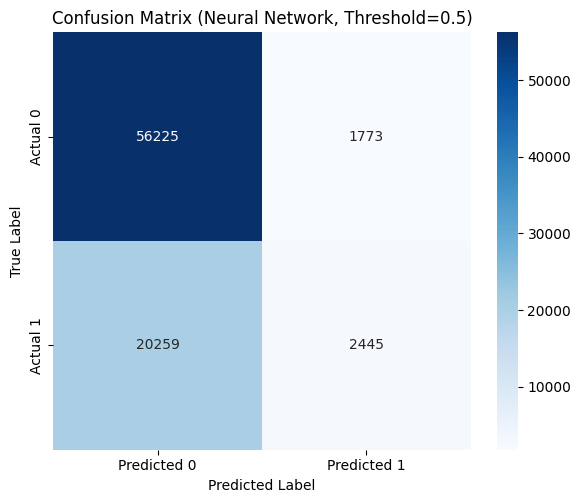

In [24]:
from sklearn.metrics import classification_report, confusion_matrix # Precision/Recall
y_nn_pred = (y_nn_prob > 0.5).astype(int)
print(classification_report(Y, y_nn_pred, digits=4))
print("Confusion Matrix:")
cm = confusion_matrix(Y, y_nn_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix (Neural Network, Threshold=0.5)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0     0.8035    0.7255    0.7625     57998
           1     0.4381    0.5468    0.4865     22704

    accuracy                         0.6752     80702
   macro avg     0.6208    0.6362    0.6245     80702
weighted avg     0.7007    0.6752    0.6849     80702

Confusion Matrix:


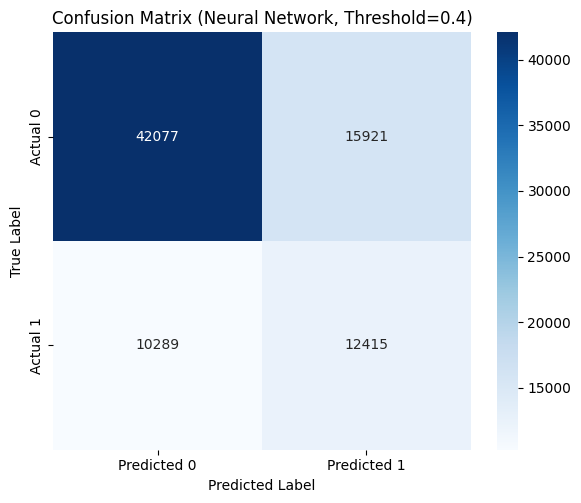

In [25]:
y_nn_pred = (y_nn_prob > 0.4).astype(int)
print(classification_report(Y, y_nn_pred, digits=4))
cm = confusion_matrix(Y, y_nn_pred)
print("Confusion Matrix:")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix (Neural Network, Threshold=0.4)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

report = classification_report(y_test, y_test_pred, digits=4)


### Random Forest test on July data

Accuracy: 72.85%

In [26]:
# test on the data in june: random forest
score = rf_model.score(X_scaled,Y)
print('score:', score)


score: 0.7284825654878442


## Out-of-Sample ROC Curve – Random Forest (July Data))

To evaluate the model's robustness, the trained Random Forest classifier was tested on data from June that was not used during training. The ROC (Receiver Operating Characteristic) curve illustrates how well the model discriminates between positive and negative classes across different probability thresholds.

* **AUC (Area Under the Curve) = 0.69**, which reflects moderate discriminatory ability on unseen data.
* The curve remains consistently above the diagonal line, indicating performance better than random guessing.
* Compared to the in-sample AUC of 0.74, the drop suggests **a slight decline in generalization**, possibly due to regime shifts or market volatility not captured during training.
* The ROC curve is smooth, confirming that the model's probabilistic predictions are reasonably calibrated.

### Conclusion

The Random Forest model retains predictive value on out-of-sample July data, although with slightly reduced performance compared to the test set. The AUC of 0.68 supports the notion that the model has learned meaningful patterns, but its ability to generalize is not as strong as the neural network (AUC ≈ 0.70).

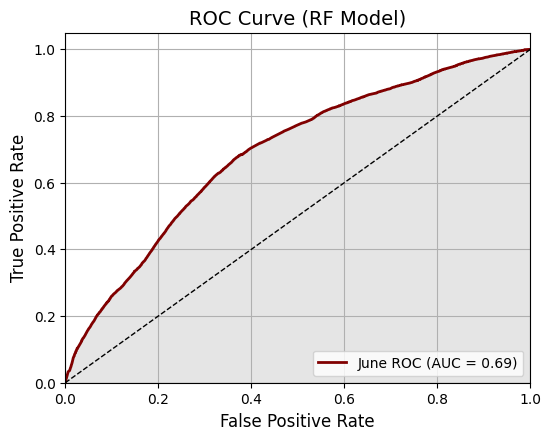

In [27]:
y_rf_prob = rf_model.predict_proba(X_scaled)[:, 1]
fpr_train, tpr_train, _ = roc_curve(Y, y_rf_prob)
roc_auc_train = auc(fpr_train, tpr_train)

plt.figure(figsize=(6, 10))

plt.subplot(2, 1, 1)
plt.plot(fpr_train, tpr_train, label='June ROC (AUC = {:.2f})'.format(roc_auc_train), color='maroon', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.fill_between(fpr_train, tpr_train, alpha=0.2, color='grey')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve (RF Model)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)


### Random Forest Performance at Different Thresholds (July Data))

To assess the impact of threshold tuning on the random forest model's ability to detect price increases, we evaluated its classification performance on July data using two probability thresholds: 0.5 (default) and 0.4 (relaxed). The results reflect how recall and precision trade off in this imbalanced setting.

1. Threshold = 0.5 (Default)

* **Class 0 (no price rise)** shows excellent recall (0.9604) and strong precision (0.7396), yielding an F1-score of 0.8356.
* **Class 1 (price rise)** suffers from low recall (0.1361), indicating the model misses most true positives in this class.
* This configuration reflects a conservative prediction strategy, with high specificity but low sensitivity for detecting rising prices.
* **Overall accuracy:** 0.7285
* **Confusion matrix:**
  + False positives: 2298
  + False negatives: 19614

2. Threshold = 0.4 (Relaxed)

* Lowering the threshold leads to a large boost in **class 1 recall**, from 0.1361 to **0.6844**, and F1-score rises significantly to **0.5159**.
* **Class 1 precision** drops from 0.5735 to 0.4140 due to more false positives, which is expected.
* **Class 0 recall** drops sharply to 0.6207, though its precision remains high (0.8340).
* **Overall accuracy:** 0.6386
* **Confusion matrix:**
  + False positives: 21997
  + False negatives: 7166

3. Conclusion

The July data confirms that lowering the classification threshold enables the random forest model to detect a significantly larger portion of true price increases (class 1), even if at the cost of more false alarms. For trading strategies where capturing upward movement is more valuable than avoiding false positives, threshold tuning to 0.4 offers a better risk-reward balance. This makes the model more viable for long-biased signal detection in high-frequency settings.

Confusion Matrix:


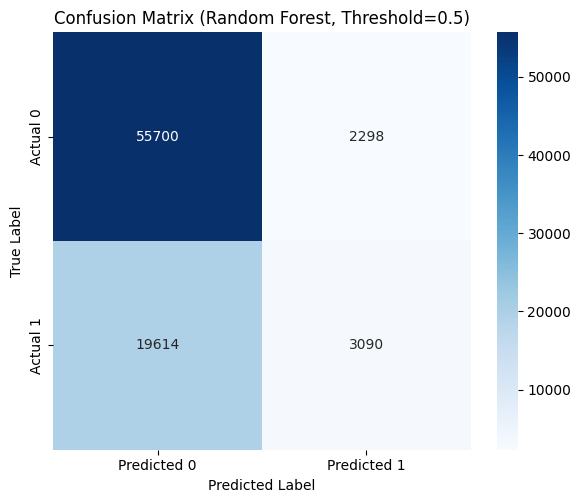

Classification Report:
              precision    recall  f1-score   support

           0     0.7396    0.9604    0.8356     57998
           1     0.5735    0.1361    0.2200     22704

    accuracy                         0.7285     80702
   macro avg     0.6565    0.5482    0.5278     80702
weighted avg     0.6928    0.7285    0.6624     80702



In [28]:
y_rf_pred = rf_model.predict(X_scaled)
cm = confusion_matrix(Y, y_rf_pred)
print("Confusion Matrix:")
cm = confusion_matrix(Y, y_rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix (Random Forest, Threshold=0.5)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

report = classification_report(Y, y_rf_pred, digits=4)
print("Classification Report:")
print(report)


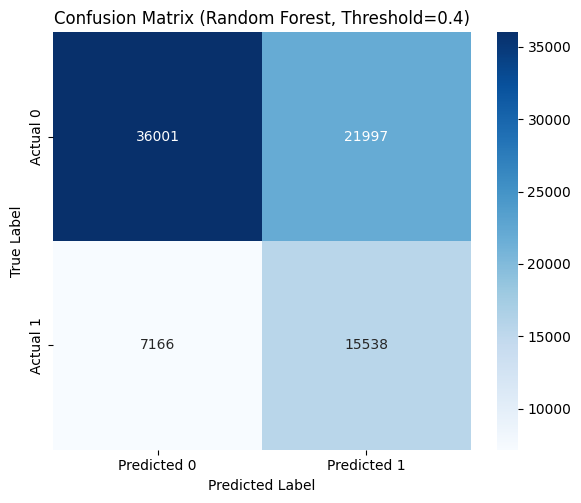

Classification Report:
              precision    recall  f1-score   support

           0     0.8340    0.6207    0.7117     57998
           1     0.4140    0.6844    0.5159     22704

    accuracy                         0.6386     80702
   macro avg     0.6240    0.6526    0.6138     80702
weighted avg     0.7158    0.6386    0.6566     80702



In [29]:
y_proba = rf_model.predict_proba(X_scaled)[:, 1]
y_proba = (y_proba > 0.4).astype(int)

cm = confusion_matrix(Y, y_proba)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix (Random Forest, Threshold=0.4)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
print("Classification Report:")
print(classification_report(Y, y_proba, digits=4))


## Conclusion

This project evaluates the predictive power of engineered limit order book (LOB) microstructure features in forecasting short-term mid-price movements. Features such as normalized spread, volume imbalance, trade pressure, and momentum showed moderate predictive utility across all models tested.

Logistic regression, while interpretable, yielded only marginal improvement over random guessing. It achieved 68.6% train accuracy and 71.9% test accuracy in March data, but struggled to capture complex non-linear patterns.

Random Forest demonstrated higher accuracy (train: 71.5%, test: 74.0%) and ROC-AUC (≈0.74), especially when trained on March data and evaluated on July. However, confusion matrices under a default threshold (y > 0.5) revealed a strong conservative bias—class 1 recall was only 11.9%, with a high number of false negatives. Lowering the threshold to y > 0.4 significantly improved recall (25.6%) and F1-score (from 0.20 to 0.35), making the model more usable for signal detection.

The neural network achieved the best balance: while its raw accuracy (~72.1%) was comparable to Random Forest, its ROC-AUC remained stable at 0.70 across both in-sample and July data. More importantly, threshold adjustment to y > 0.4 boosted class 1 recall from 0.0009 to 0.3903, raising F1-score from 0.0019 to 0.3911 with acceptable trade-offs.

Overall, the neural network emerged as the best model due to its robustness across time, flexibility under threshold tuning, and balanced class performance. Logistic regression lacks sufficient expressiveness, and Random Forest, though strong, generalizes less consistently across regimes.

# Alpha Research Extension

This section extends the original next-tick classification study into a compact hypothesis-driven alpha research workflow. The original project cells are preserved above; the additional analysis is built as a separate downstream layer.

The extension focuses on three research hypotheses:

1. **Order-flow hypothesis:** trade direction, liquidity and imbalance features contain short-horizon information about subsequent mid-price moves.
2. **Nonlinearity hypothesis:** a nonlinear model may extract incremental predictive information beyond a linear baseline.
3. **Persistence hypothesis:** microstructure information should be strongest near the signal event and weaken as the forecast lag increases.

The workflow is:

**market state → predictive probability → alpha score → signal sorting → persistence test → trading rule → transaction costs → NAV and drawdown**

## 1. Leakage-safe research dataset

The alpha extension rebuilds a compact research dataset directly from the raw TAQ files. March 12, 2024 is used for model fitting and July 11, 2024 is kept strictly out of sample.

Only information observable at the signal timestamp is used in the feature set. Future prices are created only after feature construction and are used as labels or evaluation returns. The backtest starts execution from the **next** market event rather than the signal event.

In [30]:
from scipy.stats import spearmanr

MARCH_TRADE_ZIP = "ytmorjhifybwowxl_csv.zip"
MARCH_QUOTE_ZIP = "yelqwtp7fsh6g6xo_csv.zip"
JULY_TRADE_ZIP = "kdtqhpb4rhjkzbru_csv.zip"
JULY_QUOTE_ZIP = "j9qkauhluxk44skr_csv.zip"

FEATURES_ALPHA = [
    "spread",
    "vol_imbalance",
    "microprice_disp",
    "trade_location",
    "signed_log_volume",
    "momentum",
]

LIQUIDITY_SPREAD_MAX = 0.002   # 20 bps normalized quoted spread
HORIZONS = [1, 3, 5, 10]

In [31]:
def build_alpha_dataset(trade_zip, quote_zip, start="09:30:00", end="10:30:00"):
    trade_cols = ["DATE", "TIME_M", "SYM_ROOT", "SIZE", "PRICE"]
    quote_cols = ["DATE", "TIME_M", "BID", "BIDSIZ", "ASK", "ASKSIZ", "SYM_ROOT"]

    trades = pd.read_csv(
        trade_zip,
        compression="zip",
        usecols=trade_cols,
        dtype={"SIZE": "float32", "PRICE": "float32", "SYM_ROOT": "category"},
    )
    quotes = pd.read_csv(
        quote_zip,
        compression="zip",
        usecols=quote_cols,
        dtype={
            "BID": "float32",
            "ASK": "float32",
            "BIDSIZ": "float32",
            "ASKSIZ": "float32",
            "SYM_ROOT": "category",
        },
    )

    trades["TIMESTAMP"] = pd.to_datetime(
        trades["DATE"].astype(str) + " " + trades["TIME_M"].astype(str),
        errors="coerce",
    )
    quotes["TIMESTAMP"] = pd.to_datetime(
        quotes["DATE"].astype(str) + " " + quotes["TIME_M"].astype(str),
        errors="coerce",
    )

    start_time = pd.to_datetime(start).time()
    end_time = pd.to_datetime(end).time()
    quote_start = pd.to_datetime("09:29:00").time()

    trades = trades[
        (trades["TIMESTAMP"].dt.time >= start_time)
        & (trades["TIMESTAMP"].dt.time <= end_time)
    ].copy()

    # Keep one minute of pre-open quotes so the first trades can use the latest
    # quote available at or before the trade timestamp.
    quotes = quotes[
        (quotes["TIMESTAMP"].dt.time >= quote_start)
        & (quotes["TIMESTAMP"].dt.time <= end_time)
    ].copy()

    trades = trades.dropna(subset=["TIMESTAMP", "SYM_ROOT", "PRICE", "SIZE"])
    quotes = quotes.dropna(subset=["TIMESTAMP", "SYM_ROOT", "BID", "ASK"])

    trades = trades.sort_values("TIMESTAMP")
    quotes = quotes.sort_values("TIMESTAMP")

    data = pd.merge_asof(
        trades,
        quotes,
        on="TIMESTAMP",
        by="SYM_ROOT",
        direction="backward",
        allow_exact_matches=True,
    )

    # Basic observable market-state filters.
    data = data[
        (data["BID"] > 0)
        & (data["ASK"] > data["BID"])
        & (data["BIDSIZ"] >= 0)
        & (data["ASKSIZ"] >= 0)
        & ((data["BIDSIZ"] + data["ASKSIZ"]) > 0)
    ].copy()

    data = data.sort_values(["SYM_ROOT", "TIMESTAMP"]).reset_index(drop=True)
    data["event_id"] = data.groupby("SYM_ROOT", observed=True).cumcount()

    data["mid"] = (data["ASK"] + data["BID"]) / 2.0
    data["spread"] = (data["ASK"] - data["BID"]) / data["mid"]
    depth = data["BIDSIZ"] + data["ASKSIZ"]

    data["vol_imbalance"] = (data["BIDSIZ"] - data["ASKSIZ"]) / depth

    microprice = (
        data["ASK"] * data["BIDSIZ"] + data["BID"] * data["ASKSIZ"]
    ) / depth
    data["microprice_disp"] = (microprice - data["mid"]) / data["mid"]

    half_spread = (data["ASK"] - data["BID"]) / 2.0
    trade_location = (data["PRICE"] - data["mid"]) / half_spread.replace(0, np.nan)
    data["trade_location"] = trade_location.clip(-2, 2).fillna(0)

    trade_sign = np.sign(data["PRICE"] - data["mid"])
    data["signed_log_volume"] = trade_sign * np.log1p(data["SIZE"].clip(lower=0))

    data["momentum"] = (
        data.groupby("SYM_ROOT", observed=True)["mid"]
        .pct_change()
        .fillna(0)
    )

    grouped = data.groupby("SYM_ROOT", observed=True)

    # Classification label: same basic economic target as the original project.
    data["next_mid"] = grouped["mid"].shift(-1)
    data["movement"] = (data["next_mid"] > data["mid"]).astype("int8")

    # Cumulative forward returns for alpha sorting.
    for h in HORIZONS:
        data[f"fwd_mid_ret_{h}"] = grouped["mid"].shift(-h) / data["mid"] - 1

        # One-event return observed after a lag h. This is used for signal-decay analysis.
        data[f"step_ret_lag_{h}"] = (
            grouped["mid"].shift(-(h + 1)) / grouped["mid"].shift(-h) - 1
        )

    # Backtest timing: signal at t, enter at t+1, exit 10 events after entry.
    holding_horizon = 10
    data["entry_mid_10"] = grouped["mid"].shift(-1)
    data["exit_mid_10"] = grouped["mid"].shift(-(holding_horizon + 1))
    data["entry_time_10"] = grouped["TIMESTAMP"].shift(-1)
    data["exit_time_10"] = grouped["TIMESTAMP"].shift(-(holding_horizon + 1))

    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.dropna(subset=FEATURES_ALPHA + ["next_mid"]).reset_index(drop=True)

    # Fixed, pre-specified liquidity screen based only on the current quote.
    data = data[data["spread"] <= LIQUIDITY_SPREAD_MAX].copy()

    return data.reset_index(drop=True)


train_alpha = build_alpha_dataset(MARCH_TRADE_ZIP, MARCH_QUOTE_ZIP)
test_alpha = build_alpha_dataset(JULY_TRADE_ZIP, JULY_QUOTE_ZIP)

assert train_alpha["TIMESTAMP"].max() < test_alpha["TIMESTAMP"].min()

print("Training period:", train_alpha["TIMESTAMP"].min(), "to", train_alpha["TIMESTAMP"].max())
print("OOS period:", test_alpha["TIMESTAMP"].min(), "to", test_alpha["TIMESTAMP"].max())
print("Training observations:", len(train_alpha))
print("OOS observations:", len(test_alpha))
print("Symbols:", test_alpha["SYM_ROOT"].nunique())

Training period: 2024-03-12 09:30:00.863761152 to 2024-03-12 10:29:59.942568448
OOS period: 2024-07-11 09:30:00.098857216 to 2024-07-11 10:29:58.496262912
Training observations: 51053
OOS observations: 44782
Symbols: 11


## 2. Predictive models as alpha scorers

A logistic regression is used as the interpretable linear baseline and a random forest is used as the nonlinear alternative.

All preprocessing parameters are fitted on March data only. July observations are transformed and scored with the already-fitted March objects; the OOS period is never used to refit the scaler or model.

In [32]:
X_train_alpha = train_alpha[FEATURES_ALPHA].astype(float)
y_train_alpha = train_alpha["movement"].astype(int)

X_test_alpha = test_alpha[FEATURES_ALPHA].astype(float)
y_test_alpha = test_alpha["movement"].astype(int)

alpha_scaler = StandardScaler()
X_train_scaled_alpha = alpha_scaler.fit_transform(X_train_alpha)
X_test_scaled_alpha = alpha_scaler.transform(X_test_alpha)

logit_alpha = LogisticRegression(max_iter=500, random_state=42)
logit_alpha.fit(X_train_scaled_alpha, y_train_alpha)

rf_alpha = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=100,
    random_state=42,
    n_jobs=-1,
)
rf_alpha.fit(X_train_alpha, y_train_alpha)

p_logit_train = logit_alpha.predict_proba(X_train_scaled_alpha)[:, 1]
p_logit_test = logit_alpha.predict_proba(X_test_scaled_alpha)[:, 1]
p_rf_train = rf_alpha.predict_proba(X_train_alpha)[:, 1]
p_rf_test = rf_alpha.predict_proba(X_test_alpha)[:, 1]

auc_table = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "Train AUC": [
            roc_auc_score(y_train_alpha, p_logit_train),
            roc_auc_score(y_train_alpha, p_rf_train),
        ],
        "July OOS AUC": [
            roc_auc_score(y_test_alpha, p_logit_test),
            roc_auc_score(y_test_alpha, p_rf_test),
        ],
    }
)

display(auc_table.round(4))

test_alpha["logit_prob"] = p_logit_test
test_alpha["rf_prob"] = p_rf_test

,Model,Train AUC,July OOS AUC
0,Logistic Regression,0.6734,0.6624
1,Random Forest,0.7113,0.6865


## 3. Prediction probability → alpha score

The model probability is treated as a continuous ranking signal rather than immediately converted into a 0/1 trade decision.

For a simple economic check, OOS observations are sorted into five score buckets and the average subsequent mid-price return is measured. A useful alpha signal should show an economically ordered relationship between model score and future return even when classification accuracy alone is not the objective.

,Signal Quintile,Average 5-event forward return (bps)
0,Q1,-2.673
1,Q2,-2.337
2,Q3,-2.632
3,Q4,-1.713
4,Q5,-0.767


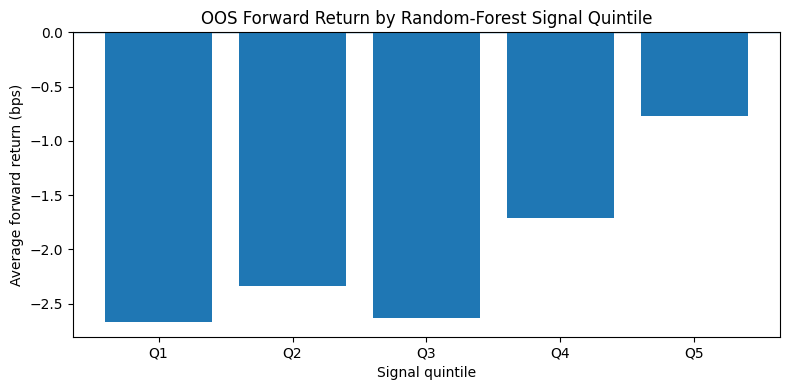

In [33]:
alpha_view = test_alpha[["rf_prob", "fwd_mid_ret_5"]].dropna().copy()
alpha_view["Signal Quintile"] = pd.qcut(
    alpha_view["rf_prob"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    duplicates="drop",
)

quintile_table = (
    alpha_view.groupby("Signal Quintile", observed=True)["fwd_mid_ret_5"]
    .mean()
    .mul(1e4)
    .rename("Average 5-event forward return (bps)")
    .reset_index()
)

display(quintile_table.round(3))

plt.figure(figsize=(8, 4))
plt.bar(
    quintile_table["Signal Quintile"].astype(str),
    quintile_table["Average 5-event forward return (bps)"],
)
plt.axhline(0, linewidth=1)
plt.title("OOS Forward Return by Random-Forest Signal Quintile")
plt.xlabel("Signal quintile")
plt.ylabel("Average forward return (bps)")
plt.tight_layout()
plt.show()

## 4. Signal persistence

To distinguish immediate microstructure information from longer-lived predictability, the signal is correlated with the **next one-event return after different lags**.

This is a cleaner persistence test than correlating the score with a longer cumulative return, because each point measures how much incremental predictive information remains after the original signal event.

,Model,Lag (events),Rank IC
0,Logistic Regression,1,0.0816
1,Logistic Regression,3,0.0218
2,Logistic Regression,5,0.0123
3,Logistic Regression,10,0.0011
4,Random Forest,1,0.0857
5,Random Forest,3,0.0204
6,Random Forest,5,0.0123
7,Random Forest,10,-0.0009


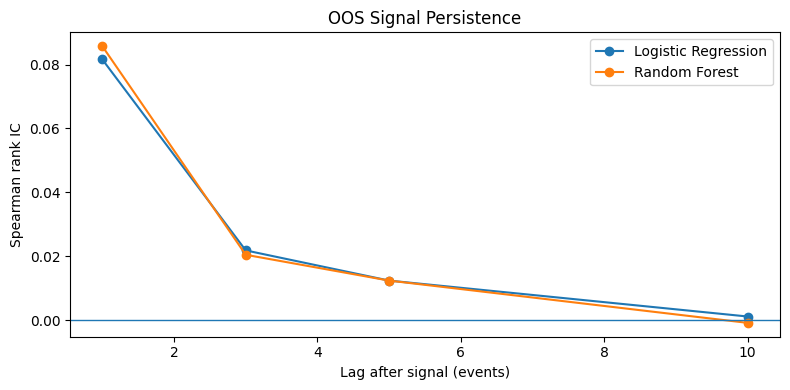

In [34]:
decay_rows = []

for model_name, score_col in [
    ("Logistic Regression", "logit_prob"),
    ("Random Forest", "rf_prob"),
]:
    for lag in HORIZONS:
        tmp = test_alpha[[score_col, f"step_ret_lag_{lag}"]].dropna()
        rank_ic = spearmanr(tmp[score_col], tmp[f"step_ret_lag_{lag}"]).statistic
        decay_rows.append(
            {
                "Model": model_name,
                "Lag (events)": lag,
                "Rank IC": rank_ic,
            }
        )

decay_table = pd.DataFrame(decay_rows)
display(decay_table.round(4))

plt.figure(figsize=(8, 4))
for model_name, grp in decay_table.groupby("Model"):
    plt.plot(grp["Lag (events)"], grp["Rank IC"], marker="o", label=model_name)
plt.axhline(0, linewidth=1)
plt.title("OOS Signal Persistence")
plt.xlabel("Lag after signal (events)")
plt.ylabel("Spearman rank IC")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Simple cost-aware trading rule

The backtest deliberately stays simple:

- Random-forest probability is the trading score.
- Long signals are above the **95th percentile** of March model scores.
- Short signals are below the **5th percentile** of March model scores.
- Thresholds are determined from the training period only.
- A signal observed at event `t` enters from event `t+1`.
- Each position is held for 10 subsequent market events.
- Trades are non-overlapping within each symbol.
- Gross returns use next-event mid-price execution for signal research.
- Net returns subtract a fixed **0.5 bp round-trip implementation cost**.

The cost assumption is a compact research approximation rather than a full exchange-level execution simulator.

In [35]:
LOW_SIGNAL_Q = 0.05
HIGH_SIGNAL_Q = 0.95
HOLDING_EVENTS = 10
ROUND_TRIP_COST_BPS = 0.5

lower_threshold, upper_threshold = np.quantile(
    p_rf_train,
    [LOW_SIGNAL_Q, HIGH_SIGNAL_Q],
)

test_alpha["position"] = np.select(
    [
        test_alpha["rf_prob"] >= upper_threshold,
        test_alpha["rf_prob"] <= lower_threshold,
    ],
    [1, -1],
    default=0,
).astype(int)

trade_rows = []

for symbol, symbol_data in test_alpha.sort_values(
    ["SYM_ROOT", "event_id"]
).groupby("SYM_ROOT", observed=True):

    next_allowed_event = -1

    for row in symbol_data.itertuples(index=False):
        event_id = int(row.event_id)

        if event_id < next_allowed_event or row.position == 0:
            continue

        entry_mid = row.entry_mid_10
        exit_mid = row.exit_mid_10
        entry_time = row.entry_time_10
        exit_time = row.exit_time_10

        if (
            pd.isna(entry_mid)
            or pd.isna(exit_mid)
            or pd.isna(entry_time)
            or pd.isna(exit_time)
            or entry_mid <= 0
            or exit_mid <= 0
            or entry_time <= row.TIMESTAMP
            or exit_time <= entry_time
        ):
            continue

        gross_ret = row.position * (exit_mid / entry_mid - 1)

        # A broad sanity bound removes only clearly broken market records.
        if abs(gross_ret) > 0.05:
            continue

        trade_rows.append(
            {
                "symbol": symbol,
                "signal_time": row.TIMESTAMP,
                "signal_event": event_id,
                "exit_event": event_id + HOLDING_EVENTS + 1,
                "position": row.position,
                "score": row.rf_prob,
                "entry_time": entry_time,
                "exit_time": exit_time,
                "gross_ret": gross_ret,
            }
        )

        next_allowed_event = event_id + HOLDING_EVENTS + 1

trades_alpha = pd.DataFrame(trade_rows)

trades_alpha["net_ret"] = (
    trades_alpha["gross_ret"]
    - ROUND_TRIP_COST_BPS * 1e-4
)


def per_trade_sharpe(returns):

    returns = pd.Series(returns).dropna()

    if len(returns) < 2:
        return np.nan

    volatility = returns.std(ddof=1)

    if volatility == 0:
        return np.nan

    return returns.mean() / volatility


# Performance statistics
gross_sharpe = per_trade_sharpe(
    trades_alpha["gross_ret"]
)

net_sharpe = per_trade_sharpe(
    trades_alpha["net_ret"]
)

gross_hit_rate = (
    trades_alpha["gross_ret"] > 0
).mean()

net_hit_rate = (
    trades_alpha["net_ret"] > 0
).mean()


print("Training-score thresholds:")
print(
    "  Lower:",
    round(lower_threshold, 4)
)
print(
    "  Upper:",
    round(upper_threshold, 4)
)

print()

print(
    "OOS trades:",
    len(trades_alpha)
)

print(
    "Long trades:",
    int(
        (trades_alpha["position"] == 1).sum()
    )
)

print(
    "Short trades:",
    int(
        (trades_alpha["position"] == -1).sum()
    )
)

print()

print(
    "Average gross return (bps):",
    round(
        trades_alpha["gross_ret"].mean()
        * 1e4,
        3,
    ),
)

print(
    "Average net return (bps):",
    round(
        trades_alpha["net_ret"].mean()
        * 1e4,
        3,
    ),
)

print()

print(
    "Gross per-trade Sharpe:",
    round(
        gross_sharpe,
        3,
    ),
)

print(
    "Net per-trade Sharpe:",
    round(
        net_sharpe,
        3,
    ),
)

print()

print(
    "Gross hit rate:",
    f"{gross_hit_rate:.2%}",
)

print(
    "Net hit rate:",
    f"{net_hit_rate:.2%}",
)

Training-score thresholds:
  Lower: 0.0978
  Upper: 0.5098

OOS trades: 2322
Long trades: 1524
Short trades: 798

Average gross return (bps): 1.561
Average net return (bps): 1.061

Gross per-trade Sharpe: 0.028
Net per-trade Sharpe: 0.019

Gross hit rate: 54.48%
Net hit rate: 52.20%


## 6. OOS NAV

Trade outcomes are aggregated into one-minute equal-weight signal returns before compounding. This prevents thousands of event-level observations from being compounded as if each were a separate full-capital portfolio.

Gross and net NAV are shown together so the economic effect of implementation costs remains visible.

,Metric,Value
0,Gross ending NAV,1.006704
1,Net ending NAV,1.003689
2,Net total return,0.003689
3,Average net trade return (bps),1.060966
4,Net trade hit rate,0.521964
5,Gross per-trade Sharpe,0.027667
6,Net per-trade Sharpe,0.018805
7,Number of trades,2322.000000


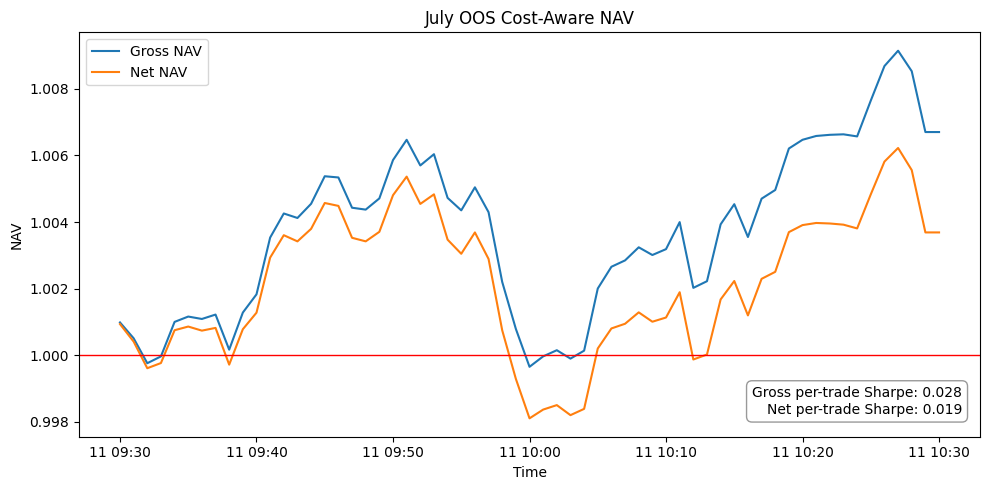

In [36]:
minute_returns = (
    trades_alpha.set_index("entry_time")[["gross_ret", "net_ret"]]
    .resample("1min")
    .mean()
)

minute_index = pd.date_range(
    test_alpha["TIMESTAMP"].min().floor("min"),
    test_alpha["TIMESTAMP"].max().ceil("min"),
    freq="1min",
)

minute_returns = minute_returns.reindex(minute_index).fillna(0)

nav_alpha = (1 + minute_returns).cumprod()
nav_alpha.columns = ["Gross NAV", "Net NAV"]

summary_table = pd.DataFrame(
    {
        "Metric": [
            "Gross ending NAV",
            "Net ending NAV",
            "Net total return",
            "Average net trade return (bps)",
            "Net trade hit rate",
            "Gross per-trade Sharpe",
            "Net per-trade Sharpe",
            "Number of trades",
        ],
        "Value": [
            nav_alpha["Gross NAV"].iloc[-1],
            nav_alpha["Net NAV"].iloc[-1],
            nav_alpha["Net NAV"].iloc[-1] - 1,
            trades_alpha["net_ret"].mean() * 1e4,
            (trades_alpha["net_ret"] > 0).mean(),
            gross_sharpe,
            net_sharpe,
            len(trades_alpha),
        ],
    }
)

display(summary_table)

plt.figure(figsize=(10, 5))

plt.plot(
    nav_alpha.index,
    nav_alpha["Gross NAV"],
    label="Gross NAV"
)

plt.plot(
    nav_alpha.index,
    nav_alpha["Net NAV"],
    label="Net NAV"
)

plt.axhline(
    1.0,
    linewidth=1,
    color="red"
)

# Display previously calculated per-trade Sharpe ratios
sharpe_text = (
    f"Gross per-trade Sharpe: {gross_sharpe:.3f}\n"
    f"Net per-trade Sharpe: {net_sharpe:.3f}"
)

plt.text(
    0.98,
    0.05,
    sharpe_text,
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        alpha=0.8,
        edgecolor="gray",
    ),
)

plt.title("July OOS Cost-Aware NAV")
plt.xlabel("Time")
plt.ylabel("NAV")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Drawdown

Drawdown is calculated from the net NAV and plotted separately from the NAV chart.

Maximum net drawdown: -0.72%


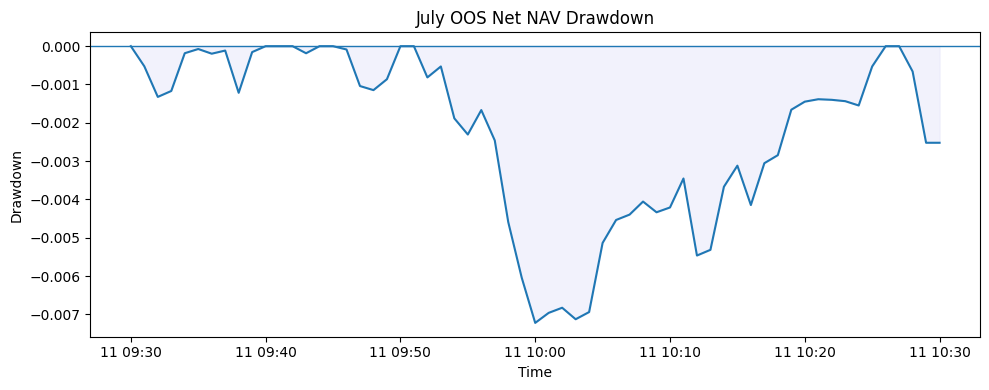

In [37]:
net_drawdown = (
    nav_alpha["Net NAV"] / nav_alpha["Net NAV"].cummax() - 1
)

print("Maximum net drawdown:", f"{net_drawdown.min():.2%}")

plt.figure(figsize=(10, 4))

plt.plot(net_drawdown.index, net_drawdown)

plt.fill_between(
    net_drawdown.index,
    net_drawdown,
    0,
    color="lavender",
    alpha=0.5
)

plt.axhline(0, linewidth=1)

plt.title("July OOS Net NAV Drawdown")
plt.xlabel("Time")
plt.ylabel("Drawdown")

plt.tight_layout()
plt.show()

## 8. Cost sensitivity

The same OOS trades can be re-evaluated under different fixed implementation-cost assumptions without refitting the model or changing signal thresholds.

In [38]:
cost_rows = []

for cost_bps in [0.0, 0.5, 1.0, 2.0]:
    temp = trades_alpha[["entry_time", "gross_ret"]].copy()
    temp["net_ret"] = temp["gross_ret"] - cost_bps * 1e-4

    temp_minute = (
        temp.set_index("entry_time")["net_ret"]
        .resample("1min")
        .mean()
        .reindex(minute_index)
        .fillna(0)
    )

    temp_nav = (1 + temp_minute).cumprod()

    cost_rows.append(
        {
            "Round-trip cost (bps)": cost_bps,
            "Ending NAV": temp_nav.iloc[-1],
            "Total return": temp_nav.iloc[-1] - 1,
        }
    )

cost_sensitivity = pd.DataFrame(cost_rows)
display(cost_sensitivity.round(6))

,Round-trip cost (bps),Ending NAV,Total return
0,0.0,1.006704,0.006704
1,0.5,1.003689,0.003689
2,1.0,1.000683,0.000683
3,2.0,0.994696,-0.005304


## 9. Backtest sanity checks

The checks below verify the main timing and NAV conditions used by the extension:

- training observations precede the OOS period;
- model fitting and score thresholds use March only;
- execution begins after the signal timestamp;
- exits occur after entries;
- trades do not overlap within a symbol;
- minute returns and NAV remain finite and within broad intraday sanity bounds.

In [39]:
assert train_alpha["TIMESTAMP"].max() < test_alpha["TIMESTAMP"].min()
assert np.isfinite(lower_threshold) and np.isfinite(upper_threshold)
assert lower_threshold < upper_threshold

assert (trades_alpha["entry_time"] > trades_alpha["signal_time"]).all()
assert (trades_alpha["exit_time"] > trades_alpha["entry_time"]).all()

for symbol, symbol_trades in trades_alpha.sort_values(
    ["symbol", "signal_event"]
).groupby("symbol"):
    signal_events = symbol_trades["signal_event"].to_numpy()
    exit_events = symbol_trades["exit_event"].to_numpy()
    if len(signal_events) > 1:
        assert np.all(signal_events[1:] >= exit_events[:-1])

assert np.isfinite(minute_returns.to_numpy()).all()
assert np.isfinite(nav_alpha.to_numpy()).all()
assert (nav_alpha.to_numpy() > 0).all()

# Broad one-hour research-backtest sanity bounds.
assert minute_returns.abs().to_numpy().max() < 0.05
assert nav_alpha["Net NAV"].max() < 1.20
assert nav_alpha["Net NAV"].min() > 0.80
assert minute_returns["net_ret"].std() > 0

print("All leakage/timing/NAV sanity checks passed.")

All leakage/timing/NAV sanity checks passed.


## 10. Research interpretation

This extension separates three questions that are often mixed together in short-horizon modelling:

1. **Predictive skill:** does the model rank future price direction out of sample?
2. **Alpha persistence:** how quickly does the information in the score decay after the signal event?
3. **Trading economics:** does the gross signal remain meaningful once trading frequency and implementation costs are introduced?

The result is a compact research workflow rather than a production HFT system. It is intended to show how market-microstructure features can be taken from a statistical prediction problem into a reproducible alpha-testing and validation process.